In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap
import pickle

In [5]:
df = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')

In [6]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
df.shape

(284807, 31)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [9]:
(df['Class'].value_counts(normalize = True)*100).round(2)

Class
0    99.83
1     0.17
Name: proportion, dtype: float64

In [10]:
# 99.83% is not in fraud and 0.17% is in fraud data is heavy imbalance

In [11]:
df.isnull().sum().sum()

np.int64(0)

In [12]:
# No null value is there

In [13]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


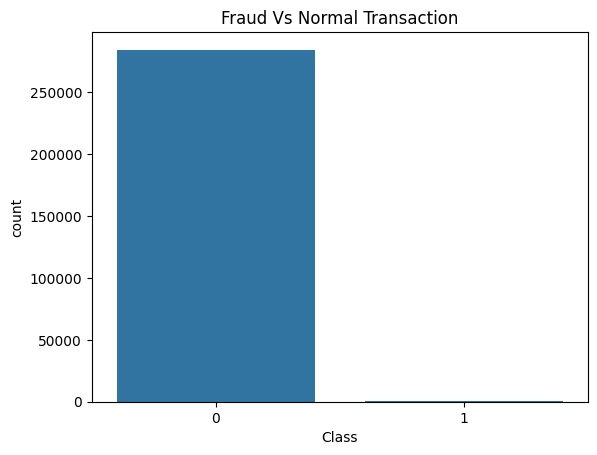

In [14]:
sns.countplot(x = 'Class',data = df)
plt.title('Fraud Vs Normal Transaction')
plt.show()

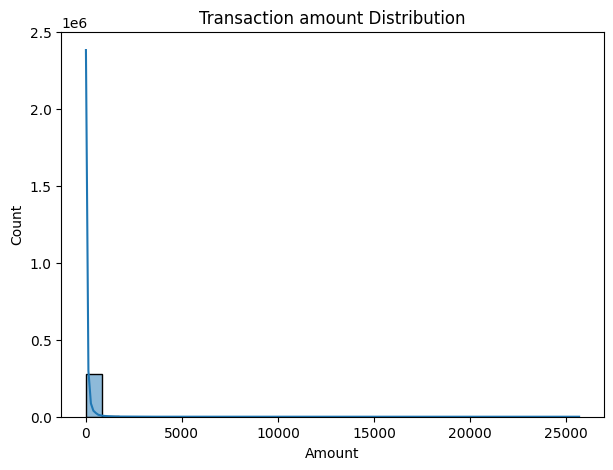

In [15]:
plt.figure(figsize = (7,5))
sns.histplot(x = 'Amount',data = df,bins = 30,kde = True)
plt.title('Transaction amount Distribution')
plt.show()

In [16]:
# not normally distributed it is skewed towards right

In [17]:
scaler = StandardScaler()

In [18]:
df[['scaled_amount','scaled_time']] = scaler.fit_transform(df[['Amount','Time']])

In [19]:
df.drop(['Amount','Time'],axis = 1,inplace = True)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   V1             284807 non-null  float64
 1   V2             284807 non-null  float64
 2   V3             284807 non-null  float64
 3   V4             284807 non-null  float64
 4   V5             284807 non-null  float64
 5   V6             284807 non-null  float64
 6   V7             284807 non-null  float64
 7   V8             284807 non-null  float64
 8   V9             284807 non-null  float64
 9   V10            284807 non-null  float64
 10  V11            284807 non-null  float64
 11  V12            284807 non-null  float64
 12  V13            284807 non-null  float64
 13  V14            284807 non-null  float64
 14  V15            284807 non-null  float64
 15  V16            284807 non-null  float64
 16  V17            284807 non-null  float64
 17  V18            284807 non-nul

In [21]:
X = df.drop(['Class'],axis = 1)
y = df['Class']

In [22]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [23]:
from imblearn.over_sampling import SMOTE

In [24]:
smote = SMOTE()

In [25]:
x_train_res,y_train_res = smote.fit_resample(x_train,y_train)

In [26]:
(y_train_res.value_counts(normalize = True)*100).round(2)

Class
0    50.0
1    50.0
Name: proportion, dtype: float64

In [27]:
# Model1 — Logistic Regression

In [28]:
lr = LogisticRegression()

In [29]:
lr.fit(x_train_res,y_train_res)

LogisticRegression()

In [30]:
y_pred_lr = lr.predict(x_test)

In [31]:
print('ClassificationReport:\n',classification_report(y_test,y_pred_lr))

ClassificationReport:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.93      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [32]:
print('ConfusionMatrix:\n',confusion_matrix(y_test,y_pred_lr))

ConfusionMatrix:
 [[55422  1442]
 [    7    91]]


In [33]:
# Model 2 — Random Forest

In [34]:
rf = RandomForestClassifier(n_estimators = 200,max_depth = 10,random_state = 42)

In [35]:
rf.fit(x_train_res,y_train_res)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [36]:
y_pred_rf = rf.predict(x_test)

In [37]:
print('ClassificationReport:\n',classification_report(y_test,y_pred_rf))

ClassificationReport:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.43      0.89      0.58        98

    accuracy                           1.00     56962
   macro avg       0.71      0.94      0.79     56962
weighted avg       1.00      1.00      1.00     56962



In [38]:
# Model 3 — XGBoost

In [39]:
xgb_model = XGBClassifier(n_estimators = 300,max_depth = 6,learning_rate = 0.05,
                         Subsample = 0.8,colsample_bytree = 0.8)

In [40]:
xgb_model.fit(x_train_res,y_train_res)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:43:22] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "Subsample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(Subsample=0.8, base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, ...)

In [41]:
y_pred_xgb = xgb_model.predict(x_test)

In [42]:
print('ClassificationReport:\n',classification_report(y_test,y_pred_xgb))

ClassificationReport:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.53      0.88      0.66        98

    accuracy                           1.00     56962
   macro avg       0.77      0.94      0.83     56962
weighted avg       1.00      1.00      1.00     56962



In [43]:
print('ConfusionMatrix:\n',confusion_matrix(y_test,y_pred_xgb))

ConfusionMatrix:
 [[56789    75]
 [   12    86]]


In [44]:
cm = confusion_matrix(y_test,y_pred_xgb)

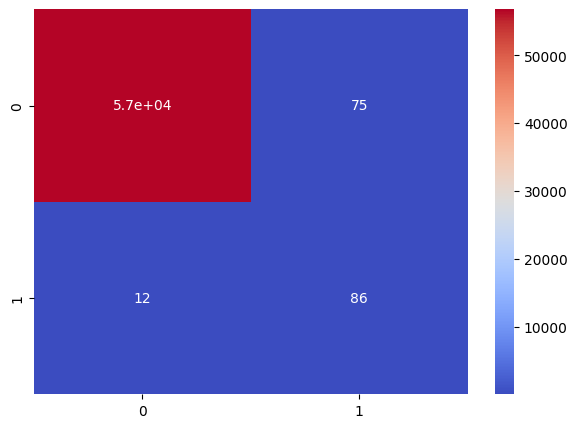

In [45]:
plt.figure(figsize = (7,5))
sns.heatmap(cm,annot = True,cmap = 'coolwarm')
plt.show()

In [46]:
# ROC AUC Score

In [47]:
y_prob = xgb_model.predict_proba(x_test)[:,1]

In [48]:
roc_score = roc_auc_score(y_test,y_prob)
print(roc_score)

0.9893596823929346


In [49]:
fpr,tpr,threshold = roc_curve(y_test,y_prob)

/tmp/ipykernel_55/666727407.py:2: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(fpr,tpr,label = ('AUC:',roc_auc_score(y_test,y_prob)))


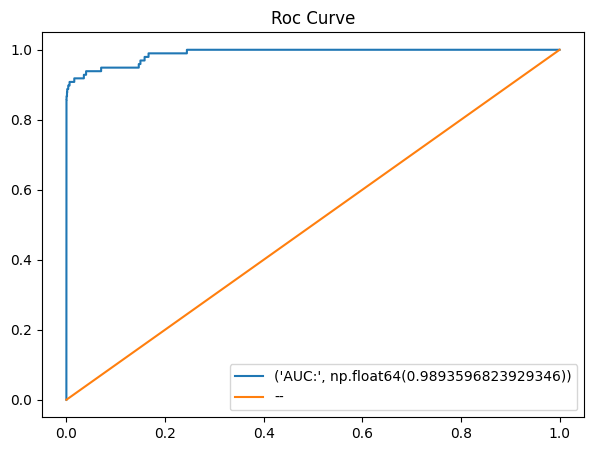

In [50]:
plt.figure(figsize = (7,5))
plt.plot(fpr,tpr,label = ('AUC:',roc_auc_score(y_test,y_prob)))
plt.plot([0,1],[0,1],label = '--')
plt.legend()
plt.title('Roc Curve')
plt.show()

In [51]:
precision,recall,_ = precision_recall_curve(y_test,y_prob)

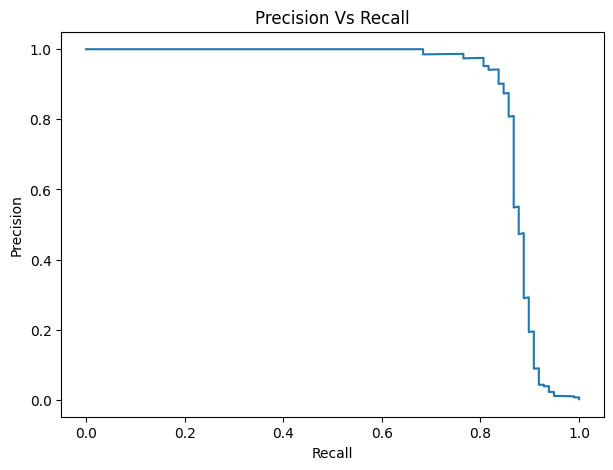

In [52]:
plt.figure(figsize = (7,5))
plt.plot(recall,precision)
plt.title('Precision Vs Recall')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

In [53]:
# SHAP
#SHAP is a method to explain machine learning model predictions. It tells you:

##Which features are most important

#How each feature impacts predictions (positively or negatively)

#Why a specific prediction was made
#Creates an explainer object specifically for tree-based models (XGBoost, Random Forest, etc.)

#The explainer learns how your model makes decisions

#It's like creating a "translator" that will convert model decisions into human-understandable explanations
#Calculates SHAP values for your test data

#SHAP values = how much each feature contributed to each prediction

#For each prediction, every feature gets a SHAP value

#Positive SHAP value = feature pushed prediction higher

#Negative SHAP value = feature pushed prediction lower
#Feature importance (features ranked top to bottom)

#Impact direction (red = high feature value, blue = low feature value)

#SHAP value (x-axis shows how much prediction changed)
#Y-axis: Features ranked by importance

#X-axis: SHAP value (impact on prediction)

#Color: Feature value (red = high, blue = low)

#Each dot: One prediction from your test data


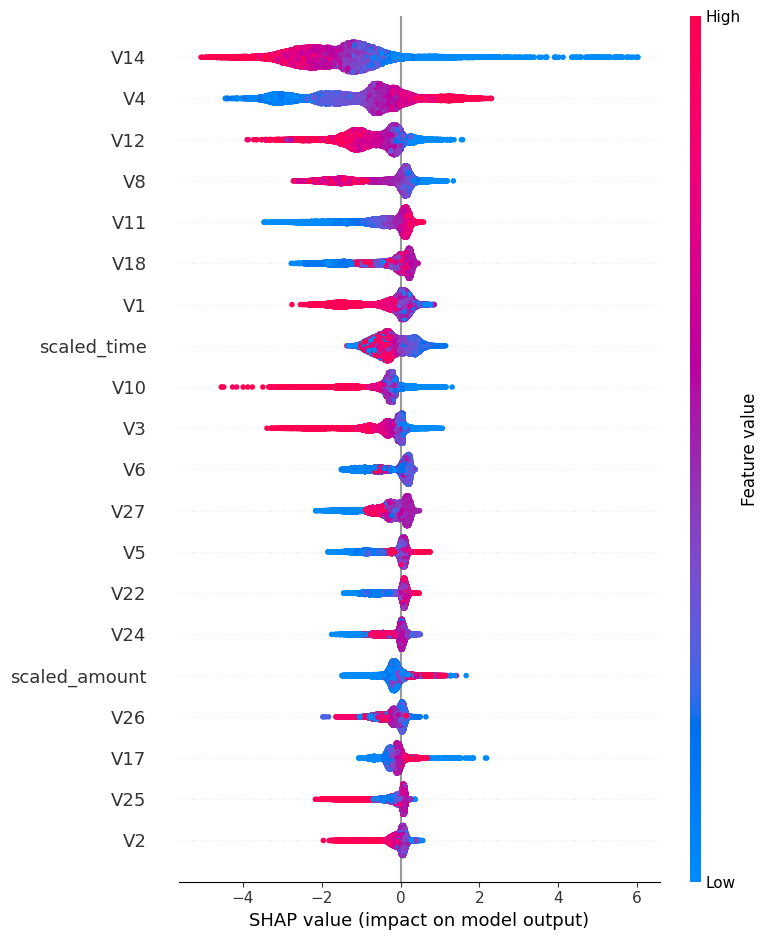

In [54]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(x_test)
shap.summary_plot(shap_values,x_test)


In [55]:
# What is Isolation Forest?
#Isolation Forest is an unsupervised algorithm specifically designed for anomaly detection.
#Unlike normal models that learn patterns of "normal" data, Isolation Forest focuses on isolating anomalies (fraud, outliers) because they are:

#Few - anomalies are rare

#Different - anomalies have unique characteristics
#Makes predictions on test data
#1 = normal/normal transaction
#-1 = anomaly/fraudulent transaction
#contamination=0.002 = expected proportion of anomalies in the data

#0.002 = 0.2% of data is fraudulent/anomalous

In [56]:
iso = IsolationForest(contamination = 0.002)

In [57]:
iso.fit(x_train)

IsolationForest(contamination=0.002)

In [58]:
y_pred_iso = iso.predict(x_test)

In [59]:
y_pred_iso = np.where(y_pred_iso == -1,1,0)

In [60]:
print(y_pred_iso)

[1 0 0 ... 0 0 0]


In [61]:
pickle.dump(xgb_model, open("fraud_xgb.pkl","wb"))
pickle.dump(scaler, open("scaler.pkl","wb"))